# Linear Regression — Predicting Turbidity from Catchment Features

Fits `eoflow.models.LinearRegression` (an OLS wrapper) to a catchment-features CSV produced
by the pipeline in `docs/PIPELINE.md` (`scripts/prepare_samples.py` → `scripts/extract_features.py`),
and does a basic accuracy analysis of how well the terrain / soil / rainfall / EO features
predict the target determinand (Turbidity by default).

---

### Contents

1. Configuration — set `DATA_PATH` and `TARGET_COLUMN` here
2. Load & inspect data
3. Train / test split
4. Fit the model
5. Holdout accuracy
6. Predicted vs. actual, and residuals
7. Leave-one-out cross-validation (robust to the small-sample regime)
8. Feature coefficients
9. Summary

---

> **Note on sample size:** the default `DATA_PATH` below points at a 5-row sample dataset
> (`catchment_features_2020_sample5.csv`), useful for exercising the notebook end-to-end but
> too small for a statistically meaningful accuracy estimate. Point `DATA_PATH` at a larger
> extract (e.g. a full-year run of `extract_features.py`) for real analysis.

## 1 — Configuration

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut, train_test_split

from eoflow.models.base import split_features_target
from eoflow.models.LinearRegression import LinearRegression

In [2]:
# ── User-editable settings ───────────────────────────────────────────────────────────────

# Path to the features CSV written by scripts/extract_features.py
DATA_PATH = Path(
    "/home/finley/Work/RDS/projects/enforce/repos/eoflow_container/outputs/catchment_features_2020_sample5.csv"
)

# Column to predict. `result` holds the measured determinand value for every row
# (its `unit` column records which determinand) — for a CSV that has already been
# filtered to Turbidity samples (as the sample5 dataset is), this *is* Turbidity.
# Point this at a different numeric column to predict something else.
TARGET_COLUMN = "result"

# Train/test split
TEST_SIZE = 0.2
RANDOM_STATE = 0

# Model hyperparameters (see eoflow.models.LinearRegression)
FIT_INTERCEPT = True
POSITIVE = False

# ──────────────────────────────────────────────────────────────────────

assert DATA_PATH.exists(), f"CSV not found: {DATA_PATH}"

ACCENT = "#3B6FE0"      # primary series (train / fitted values)
ACCENT_MUTED = "#98A6C2"  # secondary series (test / holdout)
POSITIVE_HUE = "#2E8B7A"  # positive coefficients
NEGATIVE_HUE = "#C4553D"  # negative coefficients
GRID = "#E4E7ED"

print("Data path     :", DATA_PATH)
print("Target column :", TARGET_COLUMN)

Data path     : /home/finley/Work/RDS/projects/enforce/repos/eoflow_container/outputs/catchment_features_2020_sample5.csv
Target column : result


## 2 — Load & inspect data

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Loaded 5 rows × 54 columns


,notation,site_name,date,result,unit,flow_acc_at_pour_point_log,catchment_area_km2,catchment_perimeter_km,catchment_compactness,elevation_mean_m,...,rainfall_max_mm_h,rainfall_total_depth_mm,rainfall_spatial_cv,interaction_bare_x_steep10,interaction_bare_x_steep15,interaction_erodible_x_bare,interaction_wet_x_steep10,interaction_rain_x_bare,interaction_spr_x_bare,interaction_slope_mean_x_inv_ndvi
0,SW-70220159,RIVER AXE AT WHITFORD BRIDGE,2020-02-24,13.0,NEPHELOMETRIC TURBIDITY UNITS,8.330864,2.505195,9.379614,0.357834,63.998347,...,24.71875,49.644097,3.098187,0.033663,0.005747,0.003188,0.000000,0.139559,18.819210,4.265497
1,SW-70561005,RIVER BATHERM AT BOWBIERHILL WOOD BELOW HIGHER...,2020-03-16,14.0,NEPHELOMETRIC TURBIDITY UNITS,11.097122,39.633083,36.352170,0.376883,176.750203,...,12.06250,18.735863,2.660116,0.160915,0.045460,0.000000,0.049718,0.155427,27.126389,5.958723
2,SW-70720104,RIVER DART AT TOTNES WEIR,2020-01-07,2.3,NEPHELOMETRIC TURBIDITY UNITS,13.046350,281.127979,130.695707,0.206819,297.713554,...,77.43750,6.135792,10.238715,0.081108,0.021384,0.050050,0.000524,0.041407,13.494160,5.059444
3,SW-73080442,RIVER YEO (BARNSTAPLE) AT COLLARD BRIDGE,2020-01-22,4.8,NEPHELOMETRIC TURBIDITY UNITS,11.773650,77.735123,53.027935,0.347390,205.167291,...,48.31250,25.830122,3.000431,0.000503,0.000201,0.000000,0.000021,0.000435,0.077597,2.933008
4,SW-81271202,RIVER THRUSHEL AT TINHAY BRIDGE,2020-01-06,5.9,NEPHELOMETRIC TURBIDITY UNITS,12.142435,113.458180,74.465375,0.257121,162.958303,...,5.87500,2.546180,4.369564,0.000812,0.000089,0.000016,0.000481,0.000866,0.732550,2.252016


In [4]:
assert TARGET_COLUMN in df.columns, f"{TARGET_COLUMN!r} not in columns: {list(df.columns)}"

if "unit" in df.columns:
    print("Determinand unit(s) present:")
    print(df["unit"].value_counts())

print(f"\n{TARGET_COLUMN} summary:")
df[TARGET_COLUMN].describe()

Determinand unit(s) present:
unit
NEPHELOMETRIC TURBIDITY UNITS    5
Name: count, dtype: int64

result summary:


count     5.000000
mean      8.000000
std       5.199519
min       2.300000
25%       4.800000
50%       5.900000
75%      13.000000
max      14.000000
Name: result, dtype: float64

In [5]:
# Split into predictors X and target y. This drops the identity columns
# (notation, site_name, date, result, unit) and keeps every other numeric column.
X, y = split_features_target(df, target_column=TARGET_COLUMN)

n_missing = X.isna().any(axis=1).sum()
print(f"Features: {X.shape[1]} columns")
print(f"Rows with at least one missing feature: {n_missing}/{len(X)}")
print(f"Rows with missing target: {y.isna().sum()}/{len(y)}")

Features: 49 columns
Rows with at least one missing feature: 0/5
Rows with missing target: 0/5


## 3 — Train / test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} rows   Test: {len(X_test)} rows")

if len(X_test) < 3:
    print(
        "\nWarning: very few holdout rows — the train/test split metrics below will be "
        "noisy. See section 7 for a leave-one-out estimate that uses every row."
    )

Train: 4 rows   Test: 1 rows



## 4 — Fit the model

In [7]:
model = LinearRegression(fit_intercept=FIT_INTERCEPT, positive=POSITIVE)
model.fit(X_train, y_train)

print(f"Fitted on {len(X_train)} rows × {len(model.feature_names_)} features")
print(f"Intercept: {model.intercept:.4f}")

2026-07-14 15:18:28,860 - eoflow.models.LinearRegression - INFO - Fit LinearRegression on 4 rows × 49 features.
Fitted on 4 rows × 49 features
Intercept: 20.0619
Fitted on 4 rows × 49 features
Intercept: 20.0619


## 5 — Holdout accuracy

In [8]:
train_metrics = model.score(X_train, y_train)
test_metrics = model.score(X_test, y_test)

metrics_df = pd.DataFrame([train_metrics, test_metrics], index=["train", "test"])
metrics_df

,r2,rmse,mae
train,1.0,3.108624e-15,2.886580e-15
test,NaN,2.084116e+01,2.084116e+01


## 6 — Predicted vs. actual, and residuals

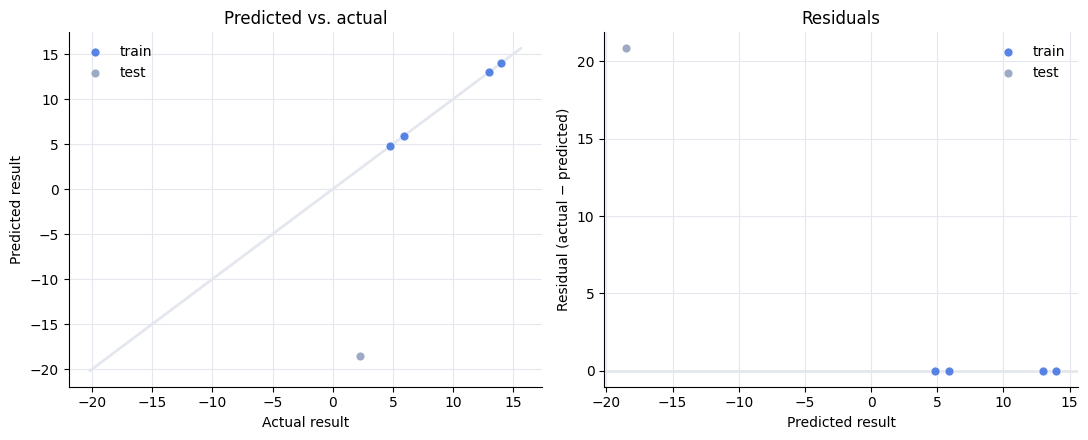

In [9]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# — Predicted vs. actual —
ax = axes[0]
all_vals = np.concatenate([y_train, y_test, y_train_pred, y_test_pred])
lo, hi = float(np.min(all_vals)), float(np.max(all_vals))
pad = 0.05 * (hi - lo if hi > lo else 1.0)
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color=GRID, lw=2, zorder=1, label="_nolegend_")
ax.scatter(y_train, y_train_pred, s=42, color=ACCENT, alpha=0.85, edgecolor="white", linewidth=0.6, label="train", zorder=2)
ax.scatter(y_test, y_test_pred, s=42, color=ACCENT_MUTED, alpha=0.95, edgecolor="white", linewidth=0.6, label="test", zorder=3)
ax.set_xlabel(f"Actual {TARGET_COLUMN}")
ax.set_ylabel(f"Predicted {TARGET_COLUMN}")
ax.set_title("Predicted vs. actual")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False)

# — Residuals —
ax = axes[1]
resid_train = np.asarray(y_train) - y_train_pred
resid_test = np.asarray(y_test) - y_test_pred
ax.axhline(0, color=GRID, lw=2, zorder=1)
ax.scatter(y_train_pred, resid_train, s=42, color=ACCENT, alpha=0.85, edgecolor="white", linewidth=0.6, label="train", zorder=2)
ax.scatter(y_test_pred, resid_test, s=42, color=ACCENT_MUTED, alpha=0.95, edgecolor="white", linewidth=0.6, label="test", zorder=3)
ax.set_xlabel(f"Predicted {TARGET_COLUMN}")
ax.set_ylabel("Residual (actual − predicted)")
ax.set_title("Residuals")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

## 7 — Leave-one-out cross-validation

A single train/test split is unstable on small datasets — which row ends up in the
holdout set can swing the metrics a lot. Leave-one-out (LOO) refits the model once
per row, holding that row out, and pools every out-of-sample prediction into one set
of accuracy metrics. It's more expensive but uses every row as a test point exactly
once, giving a steadier estimate — especially useful while the sample dataset is
this small.

In [10]:
loo = LeaveOneOut()
y_true_loo, y_pred_loo = [], []

for train_idx, holdout_idx in loo.split(X):
    fold_model = LinearRegression(fit_intercept=FIT_INTERCEPT, positive=POSITIVE)
    fold_model.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_pred_loo.append(fold_model.predict(X.iloc[holdout_idx])[0])
    y_true_loo.append(y.iloc[holdout_idx].to_numpy()[0])

y_true_loo = np.asarray(y_true_loo, dtype=float)
y_pred_loo = np.asarray(y_pred_loo, dtype=float)
resid_loo = y_true_loo - y_pred_loo

ss_res = float(np.sum(resid_loo**2))
ss_tot = float(np.sum((y_true_loo - y_true_loo.mean()) ** 2))
loo_metrics = {
    "r2": 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan"),
    "rmse": float(np.sqrt(np.mean(resid_loo**2))),
    "mae": float(np.mean(np.abs(resid_loo))),
}

metrics_df.loc["loo"] = loo_metrics
metrics_df

2026-07-14 15:18:29,295 - eoflow.models.LinearRegression - INFO - Fit LinearRegression on 4 rows × 49 features.
2026-07-14 15:18:29,301 - eoflow.models.LinearRegression - INFO - Fit LinearRegression on 4 rows × 49 features.
2026-07-14 15:18:29,307 - eoflow.models.LinearRegression - INFO - Fit LinearRegression on 4 rows × 49 features.
2026-07-14 15:18:29,313 - eoflow.models.LinearRegression - INFO - Fit LinearRegression on 4 rows × 49 features.
2026-07-14 15:18:29,319 - eoflow.models.LinearRegression - INFO - Fit LinearRegression on 4 rows × 49 features.


,r2,rmse,mae
train,1.000000,3.108624e-15,2.886580e-15
test,NaN,2.084116e+01,2.084116e+01
loo,-5.737102,1.207104e+01,1.099525e+01


## 8 — Feature coefficients

Coefficients from the model fitted on the full training split (section 4), largest
`TOP_N_COEFS` by magnitude. Because features are on very different scales (fractions in
`[0, 1]` vs. `catchment_area_km2` in the hundreds), a large coefficient does not
necessarily mean an important feature — treat this as a sign/direction check rather
than a feature-importance ranking.

Showing the 20 largest-magnitude coefficients of 49.


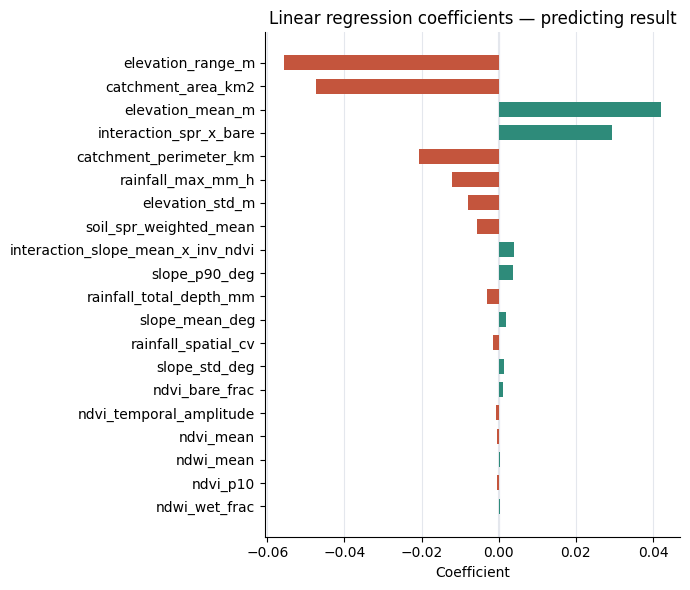

In [11]:
TOP_N_COEFS = 20

coefs = model.coefficients.reindex(model.coefficients.abs().sort_values().index)
if len(coefs) > TOP_N_COEFS:
    coefs = coefs.iloc[-TOP_N_COEFS:]
    print(f"Showing the {TOP_N_COEFS} largest-magnitude coefficients of {len(model.coefficients)}.")
colors = [POSITIVE_HUE if c >= 0 else NEGATIVE_HUE for c in coefs]

fig, ax = plt.subplots(figsize=(7, max(3, 0.3 * len(coefs))))
ax.barh(coefs.index, coefs.to_numpy(), color=colors, height=0.65)
ax.axvline(0, color=GRID, lw=1.5, zorder=0)
ax.set_xlabel("Coefficient")
ax.set_title(f"Linear regression coefficients — predicting {TARGET_COLUMN}")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, axis="x", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## 9 — Summary

In [12]:
print(f"Dataset      : {DATA_PATH.name}  ({len(df)} rows)")
print(f"Target       : {TARGET_COLUMN}")
print(f"Features     : {len(model.feature_names_)}")
print()
print("Accuracy (R² / RMSE / MAE):")
print(metrics_df.round(4).to_string())
print()
print(
    "Note: with a handful of rows these metrics are illustrative only — re-run against "
    "a larger extract_features.py output for a meaningful accuracy read."
)

Dataset      : catchment_features_2020_sample5.csv  (5 rows)
Target       : result
Features     : 49

Accuracy (R² / RMSE / MAE):
           r2     rmse      mae
train  1.0000   0.0000   0.0000
test      NaN  20.8412  20.8412
loo   -5.7371  12.0710  10.9952

Note: with a handful of rows these metrics are illustrative only — re-run against a larger extract_features.py output for a meaningful accuracy read.
